In [24]:
# ── Cell 1: imports ───────────────────────────────────────────────────────────
import io
import warnings
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
%pip install osmnx
%pip install mapclassify
 
# Suppress SSL warnings globally (macOS certificate issue workaround)
warnings.filterwarnings("ignore", message="Unverified HTTPS request")

Note: you may need to restart the kernel to use updated packages.
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 10.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 20.7 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [mapclassify] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [25]:
# ── Cell 2: load London borough boundaries ────────────────────────────────────
boroughs_url = (
    "https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master"
    "/json/administrative/eng/lad.json"
)
response = requests.get(boroughs_url, verify=False)
boroughs = gpd.read_file(io.BytesIO(response.content))
 
london_names = [
    "City of London", "Barking and Dagenham", "Barnet", "Bexley", "Brent",
    "Bromley", "Camden", "Croydon", "Ealing", "Enfield", "Greenwich",
    "Hackney", "Hammersmith and Fulham", "Haringey", "Harrow", "Havering",
    "Hillingdon", "Hounslow", "Islington", "Kensington and Chelsea",
    "Kingston upon Thames", "Lambeth", "Lewisham", "Merton", "Newham",
    "Redbridge", "Richmond upon Thames", "Southwark", "Sutton",
    "Tower Hamlets", "Waltham Forest", "Wandsworth", "Westminster",
]
boroughs = boroughs[boroughs["LAD13NM"].isin(london_names)].copy()
boroughs = boroughs.rename(columns={"LAD13NM": "name"})[["name", "geometry"]]
boroughs = boroughs.set_crs("EPSG:4326")
print(f"Boroughs loaded: {len(boroughs)}")

Boroughs loaded: 33


In [26]:
# ── Cell 3: fetch parks using osmnx ──────────────────────────────────────────
import osmnx as ox

# Fetch all park polygons within London
parks = ox.features_from_place(
    "London, United Kingdom",
    tags={"leisure": "park"},
)

# Keep only polygon geometries (discard points/lines)
parks = parks[parks.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
parks = parks[["geometry"]].reset_index(drop=True)
parks["name"] = parks.index.astype(str)  # placeholder name column
parks = gpd.GeoDataFrame(parks, crs="EPSG:4326")
print(f"Park polygons fetched: {len(parks)}")

Park polygons fetched: 3236


In [27]:
# ── Cell 4: project to British National Grid (metres) ────────────────────────
CRS = "EPSG:27700"
boroughs_m = boroughs.to_crs(CRS)
parks_m    = parks.to_crs(CRS)
 
boroughs_m["borough_area_m2"] = boroughs_m.geometry.area
print(boroughs_m[["name", "borough_area_m2"]].head())

                     name  borough_area_m2
293        City of London     2.899622e+06
294  Barking and Dagenham     3.610815e+07
295                Barnet     8.679966e+07
296                Bexley     6.059745e+07
297                 Brent     4.322336e+07


In [28]:
# ── Cell 5: overlay — green space area per borough ───────────────────────────
intersection = gpd.overlay(
    parks_m[["geometry"]],          # exclude the 'name' column from parks
    boroughs_m[["name", "geometry"]],
    how="intersection"
)
intersection["green_area_m2"] = intersection.geometry.area

green_by_borough = (
    intersection.groupby("name")["green_area_m2"]
    .sum()
    .reset_index()
)

boroughs_m = boroughs_m.merge(green_by_borough, on="name", how="left")
boroughs_m["green_area_m2"] = boroughs_m["green_area_m2"].fillna(0)
boroughs_m["green_pct"]     = (
    boroughs_m["green_area_m2"] / boroughs_m["borough_area_m2"] * 100
)

print(boroughs_m[["name", "green_pct"]].sort_values("green_pct", ascending=False))

                      name  green_pct
26    Richmond upon Thames  35.492749
23                  Merton  22.115123
32             Westminster  19.615787
11                 Hackney  18.679708
31              Wandsworth  18.156643
6                   Camden  15.620929
29           Tower Hamlets  12.671495
25               Redbridge  11.307476
22                Lewisham  11.069287
7                  Croydon  10.880550
13                Haringey  10.720450
17                Hounslow  10.716658
1     Barking and Dagenham  10.457378
10               Greenwich   9.776175
12  Hammersmith and Fulham   9.719884
8                   Ealing   9.127199
21                 Lambeth   9.034619
2                   Barnet   8.872691
15                Havering   8.730584
27               Southwark   8.304335
28                  Sutton   8.020137
9                  Enfield   7.951709
24                  Newham   7.606979
4                    Brent   7.546244
3                   Bexley   6.171357
16          

In [29]:
# ── Cell 6: distance to nearest park centroid ─────────────────────────────────
borough_centroids = boroughs_m.copy()
borough_centroids["geometry"] = borough_centroids.geometry.centroid
 
park_centroids = parks_m.copy()
park_centroids["geometry"] = park_centroids.geometry.centroid
 
joined = gpd.sjoin_nearest(
    borough_centroids[["name", "geometry"]],
    park_centroids[["geometry"]],
    how="left",
    distance_col="dist_to_park_m",
)
dist_by_borough = joined.groupby("name")["dist_to_park_m"].min().reset_index()
boroughs_m = boroughs_m.merge(dist_by_borough, on="name", how="left")

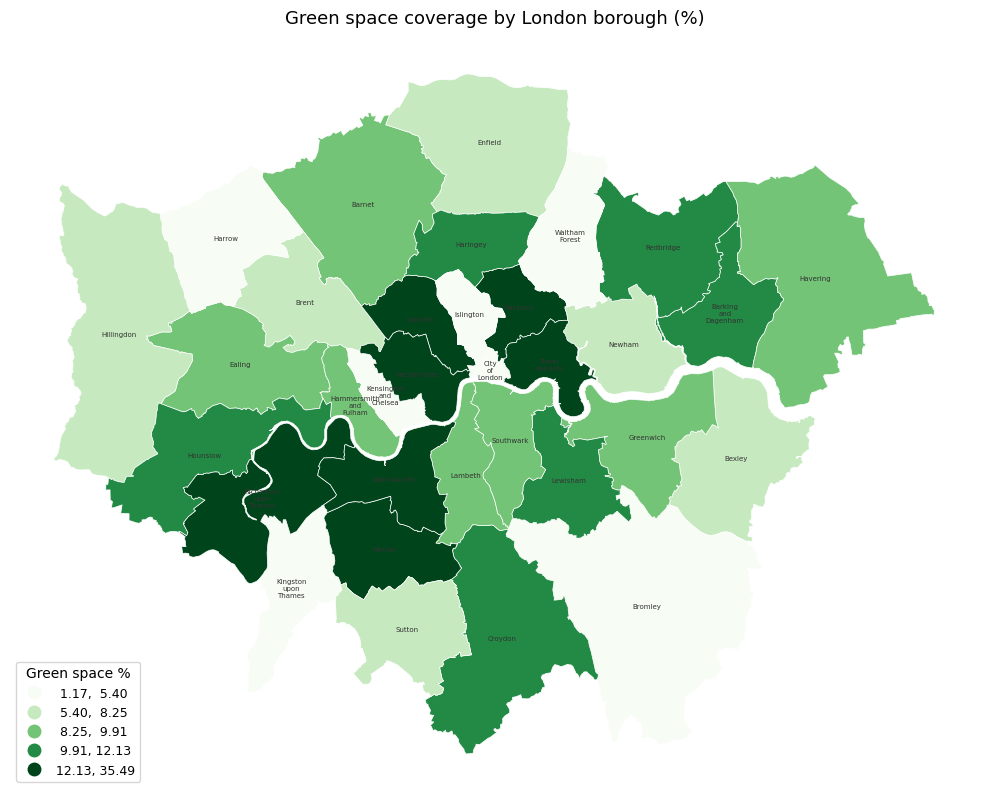

In [30]:
# ── Cell 7: choropleth — green space coverage % ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
boroughs_m.plot(
    column="green_pct",
    ax=ax,
    cmap="Greens",
    scheme="quantiles",
    k=5,
    legend=True,
    legend_kwds={"title": "Green space %", "loc": "lower left", "fontsize": 9},
    edgecolor="white",
    linewidth=0.5,
)
for _, row in boroughs_m.iterrows():
    ax.annotate(
        row["name"].replace(" ", "\n"),
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", va="center", fontsize=5, color="#333",
    )
ax.set_title("Green space coverage by London borough (%)", fontsize=13, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("green_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

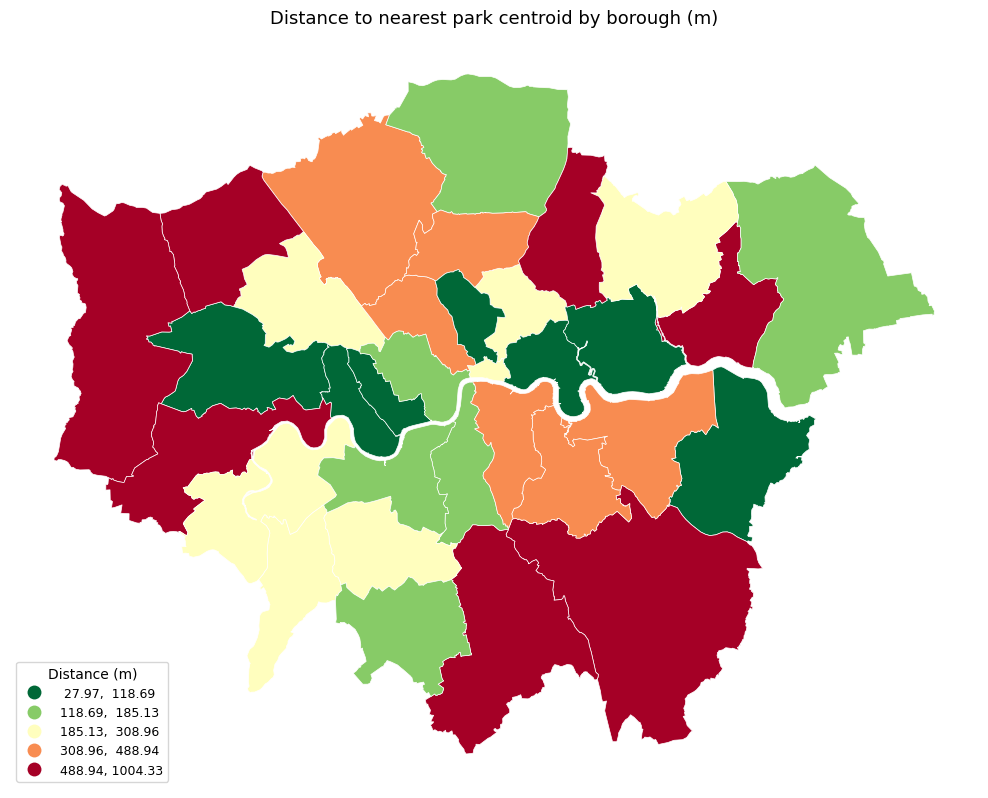

In [31]:
# ── Cell 8: choropleth — distance to nearest park ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
boroughs_m.plot(
    column="dist_to_park_m",
    ax=ax,
    cmap="RdYlGn_r",
    scheme="quantiles",
    k=5,
    legend=True,
    legend_kwds={"title": "Distance (m)", "loc": "lower left", "fontsize": 9},
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title("Distance to nearest park centroid by borough (m)", fontsize=13, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("green_distance.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ── Cell 9: ranked summary table ─────────────────────────────────────────────
summary = boroughs_m[["name", "green_pct", "dist_to_park_m"]].copy()
summary["green_pct"]      = summary["green_pct"].round(1)
summary["dist_to_park_m"] = summary["dist_to_park_m"].round(0).astype(int)
summary = summary.sort_values("green_pct", ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.to_string())

                      name  green_pct  dist_to_park_m
1     Richmond upon Thames       35.5             229
2                   Merton       22.1             304
3              Westminster       19.6             132
4                  Hackney       18.7             217
5               Wandsworth       18.2             157
6                   Camden       15.6             373
7            Tower Hamlets       12.7              89
8                Redbridge       11.3             288
9                 Lewisham       11.1             391
10                 Croydon       10.9             605
11                Hounslow       10.7             659
12                Haringey       10.7             384
13    Barking and Dagenham       10.5             526
14               Greenwich        9.8             449
15  Hammersmith and Fulham        9.7              70
16                  Ealing        9.1              28
17                 Lambeth        9.0             162
18                  Barnet  